# RAG

Basado en los datos sintéticos utilizados en clase, generar 40 documentos sintéticos adicionales usando su LLM de preferencia. Solicitar al mismo LLM que plantee 20 preguntas adicionales con respuestas correctas para simular un ground truth. Escriba un código de Agentic RAG y plantee al menos 4 modelos diferentes manipulando los siguientes hiper-parámetros:

1) system prompt

2) embedding function

3) arquitectura agéntica

Evaluar los resultados de los modelos mediante RAGAS y compare los resultados. Escriba un párrafo corto analizando las razones de las diferencias de las métricas en modelos.

## 0. Setup

In [76]:
from dotenv import load_dotenv
load_dotenv()

from langchain_community.document_loaders import PyMuPDFLoader
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore # No need for chroma for such a simple example
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode

from settings import DATA_DIR # custom data dir for my general data files, since I don't want to put them in the repo
from IPython.display import Image, display
import ftfy
from typing import Literal, Annotated
import random
import json
from pathlib import Path
from collections import Counter
from operator import add

from pydantic import BaseModel
from openai import OpenAI

In [95]:
MODEL_NAME = "gpt-4.1-mini"
EVALUATION_MODEL = "gpt-4.1-mini"
EMBEDDING_MODEL_NAME = "text-embedding-3-small"


## 1. Vector store setup

I won't actually use any fake documents. Since this is exactly my job, I will be using the real examples that I have to deal with: documents related to the employment standards legislation of Canada. For simplicity, I will just be using 1 of the 11 provincial legislations, since otherwise the problem would scale a bit too much:
- Ontario (ON): https://www.ontario.ca/laws/statute/00e41

The employment standars are highly complex documents with a very specific structure: 
1. Parts: The general organization of sections. Examples: Payment of wages, Vacations
2. Sections: They numerated and titled text divisions. If they are a bit long or describe nuance and case-specific information, they may be further divided into subsections. 

This is an example taken from ON (excerpt):
```
PART V - PAYMENT OF WAGES

Payment of wages

11 (1) An employer shall establish a recurring pay period and a recurring pay day and shall pay all wages earned during each pay period, other than accruing vacation pay, no later than the pay day for that period.  2000, c. 41, s. 11 (1).

Method of payment

(2) An employer shall pay an employee’s wages,
(a) by cash;
(b) by cheque payable only to the employee;

Statement re wages

12 (1) On or before an employee’s pay day, the employer shall give to the employee a written statement setting out,

(a) the pay period for which the wages are being paid;
(b) the wage rate, if there is one;

(2) Repealed: 
```

Sections start after a title, like in this case `Payment of wages` or `Statement re wages`, and they are numerated with a single number. Subsections, if present, also usually have titles, but they are simple descriptions and not as informative as the sections titles. They are numerated in parentheses. 

The main challenge we face when performing RAG on such documents are:
- **Content preservation**: Since these are legal documents, sections and subsections have to be retrieved intact. Chunking arbitrarily based on character is naive and even dangerous, as it could lead to incorrect or incomplete interpretations of the law.
- **Interconnectedness**: Legal documents are full of references, which require complex navigation to fully answer a complex query. Mere similarity search is incapable of performing such feats.

For starters, let's load and chunk our document.

In [96]:
loader = PyMuPDFLoader(
    f"{DATA_DIR}/nlp/esa_on.pdf",  # downlaoded manually, we could also use http content extraction directly here
)
docs = loader.load()

# Fix encoding errors in the loaded documents using ftfy (fix text for you)
for doc in docs:
    doc.page_content = ftfy.fix_text(doc.page_content)

In [5]:
print("=" * 50 + " METADATA " + "=" * 50)
print(docs[1].metadata)  # metadata includes page number and source file
print("=" * 50 + " CONTENT " + "=" * 50)
print(docs[1].page_content) 

================================================== METADATA ==================================================
{'producer': 'cairo 1.18.0 (https://cairographics.org)', 'creator': 'Zen Browser 150.0.3', 'creationdate': '2026-05-18T10:08:39-05:00', 'source': '/home/docampor/usfq-mmia/data/nlp/esa_on.pdf', 'file_path': '/home/docampor/usfq-mmia/data/nlp/esa_on.pdf', 'total_pages': 258, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': "D:20260518100839-05'00", 'page': 1}
================================================== CONTENT ==================================================
Table of contents
 
PART I
DEFINITIONS
Definitions
1 (1) In this Act,
"agent" includes a trade union that represents an employee in collective bargaining;
("mandataire")
"alternative  vacation  entitlement  year"  means,  with  respect  to  an  employee,  a
recurring 12-month period that begins on a date chosen by the employe

In [6]:
len(docs) # Loaded all pages as separate documets

258

In [97]:
# We go for a single embedding function, since it's well know that openai's 
# embedding models are pretty good at handling a wide variety of text
embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL_NAME)
vector_store = InMemoryVectorStore(embeddings)

In [99]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1024,  # rather large to preserve integrity of the information
    chunk_overlap=256,  # chunk overlap (characters)
    add_start_index=True,  # track index in original document
)
all_splits = text_splitter.split_documents(docs)

print(f"Split ESA into {len(all_splits)} sub-documents.")

Split ESA into 634 sub-documents.


In [100]:
rand_int = random.randint(0, len(all_splits) - 1)
all_splits[rand_int].page_content

'2021, c. 9, s. 3.\nHearing not required\n(14) The Board is not required to hold a hearing when making a determination or\nexercising a power under this section. 2021, c. 9, s. 3.\nNo complaint\n(15) Section 96 does not apply to a determination made by the Board under this section.\n2021, c. 9, s. 3.\nOverpayments\n(16) If the Board pays an employer an amount in excess of the amount to which the\nemployer is entitled under this section, the amount of the excess is an overpayment and\nis an amount owing under this Act. 2021, c. 9, s. 3.\nSame\n(17) If the Board pays an employer an amount under this section and the employee in\nrespect  of  whom  the  employer  was  paid  subsequently  receives  benets  under  the\nWorkplace Safety and Insurance Act, 1997 for the days of leave for which the employer was\npaid, the amount of the payment to the employer is an overpayment and is an amount\nowing under this Act. 2021, c. 9, s. 3.\nSame\n(18) An overpayment made by the Board under this sectio

In [101]:
document_ids = vector_store.add_documents(documents=all_splits)
print(document_ids[:3])

['c57c99fe-8094-4a7a-aa81-e0885dfb60f7', '59baff30-c288-4465-b228-ffe918bfa385', '966264d0-cdca-4aed-b78f-036c3eb6dc36']


## 2. RAG variants

There are many ways in which we may attempt to overcome the challenges mentioned before, but some of them require a lot work (something like setting up a Graph RAG or using Late retrieval interaction, for instance). Thus, we will see how far we can get with the four rather simple model variants:
- Base Agentic RAG: Simple graph with retrieval as a tool
- Agentic RAG + query rewriting node
- Agentic RAG + chunk filtering node.
- Agentic RAG + query rewriting node + chunk filtering node

Adding extra nodes progressively will give us insight into the real impact of each additional node, and at the end we use both at the same time to see if their combined contribution is greater than the individual one.

Some notes:
- All models will use the same answer generation prompt. The other prompts are necessarily different since their respective nodes are different.

### Setup

In [102]:
llm = ChatOpenAI(model=MODEL_NAME)

In [103]:
# System prompts
sys_msg = SystemMessage(
    content="""You are a helpful assistant that helps answer questions about Employment Standards from Ontario. 
    
    To do so, you have the following tool at your disposal:
    - retrieve_context: a tool that takes in a query and returns the most relevant information based on similarity search (standard RAG retrieval). 
    Use this tool whenever you need to get more information to answer the user's question. 
    You can call it multiple times if needed, for a maximum of three rounds.
    
    Once you have all the information you need, answer the user's question as best as you can using the retrieved information. 
    If you don't know the answer, say you don't know, but make sure to use all the information you have retrieved to inform your answer.
    """
)

rewrite_sys_msg = SystemMessage(
    content="""You are a helpful assistant that helps answer questions about Employment Standards from Ontario. 
    Your task is to rewrite the user's query to make it more effective for retrieving relevant information.
    """
)

doc_filter_sys_msg = SystemMessage(
    content="""You are a helpful assistant that helps answer questions about Employment Standards from Ontario. 
    Your task is to filter retrieved documents based on their relevance to the user's query.
    You will be given a user query and a list of retrieved documents, each with its content and metadata. 
    You need to return the top 5 most relevant documents based on their content.
    Do not rewrite any of the content, just select the most relevant documents and return them in a list.
    """
)

In [136]:
# Pydantic models to structure responses
class FilteredDocs(BaseModel):
    relevant_docs: list[str]  # verbatim content of the selected documents

class AgentState(MessagesState):
    context: Annotated[list[str], add]    # accumulates retrieved chunks
    tool_call_count: Annotated[int, add]  # incremented by 1 on every tool invocation

In [135]:
# Simple query rewrite function that calls the llm with a specific system message to rewrite the user's query
def query_rewrite(query: str) -> str:
    response = llm.invoke(
        [rewrite_sys_msg, HumanMessage(content=f"User query: {query}")]
    )
    return str(response.content)


# Document filtering function that calls the llm with a specific system message to filter retrieved documents based on their relevance to the user's query.
def document_filtering(retrieved_docs: list, query: str) -> list:
    llm_structured = llm.with_structured_output(FilteredDocs)
    response = llm_structured.invoke(
        [
            doc_filter_sys_msg,
            HumanMessage(
                content=f"User query: {query}\n\nRetrieved documents:\n"
                + "\n\n".join(f"Content: {doc.page_content}" for doc in retrieved_docs)
            ),
        ]
    )
    # Match selected content strings back to original Document objects
    selected = set(response.relevant_docs)
    filtered = [d for d in retrieved_docs if d.page_content in selected]    
    
    return filtered if filtered else retrieved_docs  # fallback: return all if nothing matched

In [137]:
def make_retrieve_tool(variant: str = "base"):
    @tool(response_format="content_and_artifact")
    def retrieve_context(query: str):
        """Retrieve information to help answer a query."""
        
        # Rewrite query before retrieval
        if variant in ("rewrite", "full"):
            query = query_rewrite(query)

        retrieved_docs = vector_store.similarity_search(query, k=10)

        # Filter documents after retrieval
        if variant in ("doc_filtering", "full"):
            retrieved_docs = document_filtering(retrieved_docs, query)

        serialized = "\n\n".join(
            f"Content: {doc.page_content}" for doc in retrieved_docs
        )

        return serialized, retrieved_docs

    return retrieve_context

In [138]:
MAX_TOOL_CALLS = 3

def get_graph(variant: Literal["base", "rewrite", "doc_filtering", "full"] = "base"):
    tools = [make_retrieve_tool(variant)]
    llm_with_tools = llm.bind_tools(tools)
    tool_node = ToolNode(tools)

    def assistant(state: AgentState):
        return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

    def tools_with_context(state: AgentState):
        result = tool_node.invoke(state)
        new_chunks = [
            doc.page_content
            for msg in result["messages"]
            if hasattr(msg, "artifact") and msg.artifact
            for doc in msg.artifact
        ]
        # Return 1 as the increment value — the `add` reducer handles the addition
        return {**result, "context": new_chunks, "tool_call_count": 1}

    def route_after_assistant(state: AgentState):
        # Force answer generation once the retrieval limit is reached
        if state.get("tool_call_count", 0) >= MAX_TOOL_CALLS:
            return END

        return tools_condition(state=state)

    builder = StateGraph(AgentState)
    builder.add_node("assistant", assistant)
    builder.add_node("tools", tools_with_context)

    builder.add_edge(START, "assistant")
    builder.add_conditional_edges("assistant", route_after_assistant, ["tools", END])
    builder.add_edge("tools", "assistant")

    return builder.compile()


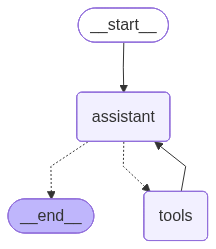

In [139]:
# Always the same diagram, only the tool changes
graph = get_graph()
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [140]:
# Simple test
state = AgentState(
    messages=[HumanMessage(content="What's the definition of an agent?")],
    context=[],
    tool_call_count=0,
)

response = graph.invoke(state)

In [141]:
response.keys()

dict_keys(['messages', 'context', 'tool_call_count'])

In [142]:
print("=" * 50)
print("Response:", response['messages'][-1].content)
print("=" * 50)
print("Tool calls:", response['tool_call_count']) # Expected at least 1, up to 3 depending on how many retrieval rounds the agent deemed necessary
print("=" * 50)
print("Context length:", len(response['context'])) # Expected: at least 10 for the simple graph
print("=" * 50)

Response: According to the Ontario Employment Standards Act, the definition of an "agent" includes a trade union that represents an employee in collective bargaining. ("agent" includes a trade union that represents an employee in collective bargaining; ("mandataire")).
Tool calls: 1
Context length: 10


In [143]:
# Test the other variants get a proper response
for variant in ("rewrite", "doc_filtering", "full"):
    print(f"Testing variant: {variant}")
    graph = get_graph(variant)
    state = AgentState(
        messages=[HumanMessage(content="What's the definition of an agent?")],
        context=[],
        tool_call_count=0,
    )
    response = graph.invoke(state)
    print("Response:", response['messages'][-1].content)
    print("Tool calls:", response['tool_call_count'])
    print("Context length:", len(response['context']))
    print("=" * 50)

Testing variant: rewrite
Response: In the Ontario Employment Standards Act, the term "agent" includes a trade union that represents an employee in collective bargaining. This is the definition provided under the Act's definitions section.
Tool calls: 1
Context length: 10
Testing variant: doc_filtering
Response: According to the Ontario Employment Standards, an "agent" includes a trade union that represents an employee in collective bargaining. The term "agent" is used in a legal and employment context and may have specific meanings depending on the situation. 

If you need a more specific definition based on a particular context, please let me know!
Tool calls: 1
Context length: 10
Testing variant: full
Response: An agent, in the context of the Employment Standards Act, refers to an agency, a recruiter, or a prospective employer who engages or uses the services of a recruiter to find or attempt to find an employee.
Tool calls: 2
Context length: 2


## 3. Evaluation dataset

In [144]:
class QAExample(BaseModel):
    question: str
    answer: str
    relevant_chunks: list[str]  # verbatim chunk texts strictly needed to answer
    difficulty: Literal['factual', 'inferential', 'reasoning']

In [145]:
qa_gen_sys_msg = SystemMessage(
    content="""You are an expert at creating question-answer pairs for evaluating RAG systems on Ontario Employment Standards legislation.
    Given a set of text chunks, generate ONE question that:
    - Matches the specified difficulty level exactly
    - Can be fully answered using only the provided chunks (not necessarily all of them)
    - Has a clear, accurate reference answer grounded in the chunk content
    - For 'factual': asks for a specific fact, number, or definition stated directly in the text
    - For 'inferential': requires connecting information across 2-3 chunks
    - For 'reasoning': requires applying rules to a scenario or comparing multiple conditions

    Return only the chunks that are strictly necessary to answer the question (verbatim from the input).
    """
)

In [146]:
DEFAULT_OUTPUT_PATH = DATA_DIR / "nlp" / "qa_examples.json"

def generate_qa_dataset(
    splits: list,
    output_path = DEFAULT_OUTPUT_PATH,
    n: int = 20,
    group_size: int = 5,
    seed: int = 42,
    regenerate: bool = False,
) -> list[QAExample]:
    """Sample n groups of group_size contiguous chunks and generate one QA pair per group.

    If output_path already exists and regenerate=False, skips generation and loads saved examples.
    Pass regenerate=True to force regeneration even if the file exists.
    """
    output_path = Path(output_path)

    if output_path.exists() and not regenerate:
        print(f"Skipping generation: loading existing examples from {output_path}")
        with open(output_path) as f:
            return [QAExample(**ex) for ex in json.load(f)]

    random.seed(seed)
    max_start = len(splits) - group_size
    start_indices = random.sample(range(max_start), n)

    # Assign difficulties evenly: 7 factual, 7 inferential, 6 reasoning
    difficulties = ["factual"] * 7 + ["inferential"] * 7 + ["reasoning"] * 6

    structured_llm = llm.with_structured_output(QAExample)
    qa_examples = []

    for i, (start, difficulty) in enumerate(zip(start_indices, difficulties)):
        chunk_group = splits[start : start + group_size]
        chunks_text = "\n\n---\n\n".join(
            f"Chunk {j+1}:\n{c.page_content}" for j, c in enumerate(chunk_group)
        )
        prompt = HumanMessage(
            content=f"Difficulty: {difficulty}\n\nChunks:\n{chunks_text}"
        )
        example = structured_llm.invoke([qa_gen_sys_msg, prompt])
        qa_examples.append(example)
        print(f"[{i+1}/{n}] {difficulty}: {example.question}")

    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "w") as f:
        json.dump([ex.model_dump() for ex in qa_examples], f, indent=2)
    print(f"\nSaved {len(qa_examples)} QA examples to {output_path}")

    return qa_examples

In [123]:
qa_examples = generate_qa_dataset(all_splits)

Skipping generation: loading existing examples from /home/docampor/usfq-mmia/data/nlp/qa_examples.json


In [124]:
qa_examples[0]

QAExample(question='Under section 28(2), what are the two options an employer has when requiring an employee in a hospital, continuous operation, hotel, motel, tourist resort, restaurant, or tavern to work on a public holiday?', answer='The employer must either: (a) pay the employee wages at his or her regular rate for the hours worked on the public holiday and give another substitute day that would ordinarily be a working day, with public holiday pay for that substitute day; or (b) pay the employee public holiday pay for the day plus premium pay for each hour worked on that day.', relevant_chunks=["28 (1) If an employee is employed in a hospital, a continuous operation, or a hotel, motel,\ntourist resort, restaurant or tavern, the employer may require the employee to work on a\npublic holiday that is ordinarily a working day for the employee and that is not a day on\nwhich the employee is on vacation, and if the employer does so, sections 26 and 27 do\nnot apply to the employee.\xa0 2

In [147]:
# Quick verification
print(f"{len(qa_examples)} QA examples loaded")
print(Counter(ex.difficulty for ex in qa_examples))

20 QA examples loaded
Counter({'factual': 7, 'inferential': 7, 'reasoning': 6})


## 4. Evaluation

### RAGAS version

Notes from the future: RAGAS sucks. Unstable, slow (a single example took minutes), full of deprecations and old documentation. I will just use another package.

In [148]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning, module='ragas')

from ragas.metrics import (
    Faithfulness,
    AnswerCorrectness,
    ResponseRelevancy,
    FactualCorrectness,
)
from ragas.dataset_schema import SingleTurnSample, EvaluationDataset
from ragas.llms import llm_factory

from ragas.embeddings import OpenAIEmbeddings as RagasOpenAIEmbeddings
import pandas as pd
from ragas import evaluate, RunConfig

/tmp/ipykernel_1872013/2403425473.py:4: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import (
/tmp/ipykernel_1872013/2403425473.py:4: DeprecationWarning: Importing AnswerCorrectness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerCorrectness
  from ragas.metrics import (
/tmp/ipykernel_1872013/2403425473.py:4: DeprecationWarning: Importing ResponseRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ResponseRelevancy
  from ragas.metrics import (
/tmp/ipykernel_1872013/2403425473.py:4: DeprecationWarning: Importing FactualCorrectness from 'ragas.metrics' is deprecated a

In [149]:
DEFAULT_DATASET_DIR = DATA_DIR / "nlp" / "ragas_datasets"


def run_question(
    question: str, variant: Literal["base", "rewrite", "doc_filtering", "full"] = "base"
) -> tuple[str, list[str]]:
    """Invoke the graph for one question and return (answer, retrieved_contexts)."""
    graph = get_graph(variant)
    state = AgentState(
        messages=[HumanMessage(content=question)],
        context=[],
        tool_call_count=0,
    )
    result = graph.invoke(state)
    answer = next(
        (
            m.content
            for m in reversed(result["messages"])
            if isinstance(m, AIMessage) and not m.tool_calls
        ),
        "",
    )
    # Use the explicit context accumulated in AgentState instead of parsing ToolMessages
    return str(answer), result.get("context", [])


def build_ragas_dataset(
    qa_examples: list,
    variant: Literal["base", "rewrite", "doc_filtering", "full"] = "base",
    output_dir=DEFAULT_DATASET_DIR,
    regenerate: bool = False,
) -> EvaluationDataset:
    """Run all QA examples through a graph variant and build a RAGAS EvaluationDataset.

    Saves raw sample data to JSON so the graph does not need to be re-run on subsequent calls.
    Pass output_dir=None to skip saving (e.g. for quick smoke tests).
    Pass regenerate=True to force re-running even if the file already exists.
    """
    output_path = Path(output_dir) / f"dataset_{variant}.json" if output_dir else None

    if output_path and output_path.exists() and not regenerate:
        print(f"Loading existing dataset for '{variant}' from {output_path}")
        with open(output_path) as f:
            records = json.load(f)

        return EvaluationDataset(samples=[SingleTurnSample(**r) for r in records])

    samples = []
    for i, ex in enumerate(qa_examples):
        print(f"  [{i+1}/{len(qa_examples)}] {ex.question[:70]}...")
        answer, contexts = run_question(ex.question, variant)
        samples.append(
            SingleTurnSample(
                user_input=ex.question,
                response=answer,
                retrieved_contexts=contexts,
                reference=ex.answer,
            )
        )

    if output_path:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        with open(output_path, "w") as f:
            json.dump([s.model_dump() for s in samples], f, indent=2)
        print(f"Saved {len(samples)} samples to {output_path}")

    return EvaluationDataset(samples=samples)

In [150]:
openai_client = OpenAI()
ragas_llm = llm_factory(EVALUATION_MODEL, client=openai_client)
ragas_embeddings = RagasOpenAIEmbeddings(
    model=EMBEDDING_MODEL_NAME, client=openai_client
)

# Reduce concurrency and increase timeout to prevent TimeoutErrors
run_config = RunConfig(timeout=120, max_retries=2, max_wait=60, max_workers=2)

metrics = [
    Faithfulness(llm=ragas_llm),
    AnswerCorrectness(llm=ragas_llm),
    ResponseRelevancy(llm=ragas_llm, embeddings=ragas_embeddings),
    FactualCorrectness(llm=ragas_llm),
]

# Smoke-test: single example, single variant (output_dir=None skips saving)
dataset = build_ragas_dataset([qa_examples[0]], "base", output_dir=None)
test_result = evaluate(dataset=dataset, metrics=metrics, run_config=run_config)
test_result.to_pandas().select_dtypes("number")

KeyboardInterrupt: 

In [151]:
DEFAULT_RESULTS_DIR = DATA_DIR / "nlp" / "ragas_results"
variants = ["base", "rewrite", "doc_filtering", "full"]

In [152]:
# Step 1: Build / load datasets for all variants
print("=== Building datasets ===")
datasets = {v: build_ragas_dataset(qa_examples, v) for v in variants}

=== Building datasets ===
  [1/20] Under section 28(2), what are the two options an employer has when req...
  [2/20] Under the exceptions in subsection 3 (5), what is one example of an in...
  [3/20] Under the section on reservist leave, what is one of the circumstances...
  [4/20] Under subsection (1.2), what is one reason related to a designated inf...
  [5/20] Under the long-term illness leave provisions, what is the definition o...
  [6/20] What percentage of wages, excluding vacation pay, must an employer pay...
  [7/20] What does "Consumer Price Index" mean in this section?...
  [8/20] If the Board has commenced a hearing to review an order, refusal to is...
  [9/20] Under the overtime rules, what is the general threshold after which an...
  [10/20] Under the regulation-making powers in subsection (1), which paragraph ...
  [11/20] If an assignment employee worked for more than one client of a tempora...
  [12/20] Under section 4, when associated or related activities or busines

In [ ]:
# Step 2: Run evaluation and save per-sample scores
print("\n=== Running evaluation ===")
results_dir = Path(DEFAULT_RESULTS_DIR)
results_dir.mkdir(parents=True, exist_ok=True)

eval_results = {}
for variant, dataset in datasets.items():
    print(f"\n{'-'*40}\nEvaluating: {variant}")
    result = evaluate(dataset=dataset, metrics=metrics, run_config=run_config)
    eval_results[variant] = result
    result_path = results_dir / f"eval_{variant}.json"
    result.to_pandas().to_json(result_path, orient="records", indent=2)
    print(f"  Saved to {result_path}")

# Step 3: Aggregate mean scores per variant
scores_df = pd.DataFrame(
    {
        variant: result.to_pandas().select_dtypes("number").mean()
        for variant, result in eval_results.items()
    }
).T

scores_df.style.highlight_max(axis=0, color="lightgreen").format("{:.3f}")


## openevals variant

Alternative evaluation using [openevals](https://github.com/langchain-ai/openevals) (LLM-as-judge, no async batching):

| openevals metric | RAGAS equivalent |
|---|---|
| `groundedness` | Faithfulness |
| `correctness` | AnswerCorrectness + FactualCorrectness |
| `relevance` | ResponseRelevancy |

One less metric but more stable and much simpler to setup.


In [153]:
from openevals.llm import create_llm_as_judge
from openevals.prompts import (
    RAG_GROUNDEDNESS_PROMPT,  # ~ Faithfulness: is the answer grounded in context?
    CORRECTNESS_PROMPT,  # ~ AnswerCorrectness: does the answer match the reference?
    ANSWER_RELEVANCE_PROMPT,  # ~ ResponseRelevancy: is the answer relevant to the question?
)

oe_graders = {
    "groundedness": create_llm_as_judge(
        prompt=RAG_GROUNDEDNESS_PROMPT, model=EVALUATION_MODEL, continuous=True
    ),
    "correctness": create_llm_as_judge(
        prompt=CORRECTNESS_PROMPT, model=EVALUATION_MODEL, continuous=True
    ),
    "relevance": create_llm_as_judge(
        prompt=ANSWER_RELEVANCE_PROMPT, model=EVALUATION_MODEL, continuous=True
    ),
}


def run_openevals(variant: str, dataset_dir=DEFAULT_DATASET_DIR) -> dict[str, float]:
    """Load a saved dataset and score it with openevals judges.

    Requires the dataset JSON files produced by build_ragas_dataset().
    """
    dataset_path = Path(dataset_dir) / f"dataset_{variant}.json"
    with open(dataset_path) as f:
        records = json.load(f)

    scores: dict[str, list[float]] = {name: [] for name in oe_graders}
    for j, r in enumerate(records):
        print(f"  [{j+1}/{len(records)}]", end="\r")
        question = r["user_input"]
        answer = r["response"]
        context = "\n\n".join(r["retrieved_contexts"])
        reference = r["reference"]

        scores["groundedness"].append(
            oe_graders["groundedness"](outputs=answer, context=context)["score"]
        )
        scores["correctness"].append(
            oe_graders["correctness"](
                inputs=question, outputs=answer, reference_outputs=reference
            )["score"]
        )
        scores["relevance"].append(
            oe_graders["relevance"](inputs=question, outputs=answer)["score"]
        )

    return {name: sum(vals) / len(vals) for name, vals in scores.items()}


# Evaluate all variants — reuses the JSON datasets built in section 4
oe_results = {}
for v in variants:
    print(f"\n{'-'*40}\nEvaluating: {v}")
    oe_results[v] = run_openevals(v)
    print(f"  scores: {oe_results[v]}")

oe_df = pd.DataFrame(oe_results).T
oe_df.style.highlight_max(axis=0, color="lightgreen").format("{:.3f}")


----------------------------------------
Evaluating: base
  scores: {'groundedness': 0.99, 'correctness': 0.9400000000000001, 'relevance': 0.975}

----------------------------------------
Evaluating: rewrite
  scores: {'groundedness': 1.0, 'correctness': 1.0, 'relevance': 1.0}

----------------------------------------
Evaluating: doc_filtering
  scores: {'groundedness': 1.0, 'correctness': 0.97, 'relevance': 1.0}

----------------------------------------
Evaluating: full
  scores: {'groundedness': 0.9875, 'correctness': 0.9875, 'relevance': 1.0}


,groundedness,correctness,relevance
base,0.990,0.940,0.975
rewrite,1.000,1.000,1.000
doc_filtering,1.000,0.970,1.000
full,0.988,0.988,1.000


## Conclusions

- The best agent variant was, surprisingly, the rewrite one with perfect scores for all three evaluation metrics. Rewriting the query seems effective to overcome the all the gaps of the base version.
- The base results were already pretty good, so it appears that the document filtering is hurting the correctness a bit, most likely because it's removing important context to fully answer the question.
- The base and rewrite models also have the advantage of significantly less latency. I don't have hard metrics, but the waiting time on the last two variants was two or three times larger that the first two.
- Our synthetic dataset is extremely simple and not realistic. I would expect all agent variants to perform much worse under real conditions.
- There are many things that I'd like to try: test on real questions, test more powerful retrieval variants, and test on several documents from different provinces. Something like a Graph RAG or a late retrieval interaction modle would be pretty interesting to test.